# 03. Meeting an Electrical Demand

The first two models were pure generation plants: everything they produced was sold to the market.
This model introduces the opposite pressure — a **fixed electrical load** that must be served in
every single hour, no matter what the weather or the price is doing.

The objective is to model the same **10 MW Solar PV + 15 MW Wind** portfolio from Model 02, but now
behind-the-meter of a **6 MW average industrial load**, with a grid connection that can both import
(to cover any shortfall) and export (to sell any surplus). The solver no longer only decides *how
much* to generate — it now decides, hour by hour, whether to **self-consume, export, or import**,
purely by minimizing cost.

## 🛠️ System Topology
1. **Buses:** A single primary electrical bus, same as Models 01 and 02.
2. **Generators (Source):** Solar PV (10 MW) and Wind (15 MW), unchanged from Model 02.
3. **Generators (Grid, two-directional):** The grid connection is now split into **two** generators
   instead of one:
   - `Grid_Import` — a normal generator (0 to `p_nom`) priced at the Day-Ahead market price, used to
     cover any load the on-site renewables can't meet.
   - `Grid_Export` — the same market-sink pattern from Models 01 and 02 (bounded between -1 p.u. and
     0 p.u.), used to sell any renewable surplus once the load is satisfied.
4. **Loads:** A fixed industrial `Load` on the electricity bus, averaging 6 MW with a simple
   day/night shape (higher during working hours, lower overnight).

Because solar and wind have €0 marginal cost, the solver will always prefer to use them to meet the
load before reaching for `Grid_Import` (which costs the market price). Only once the load is fully
covered does any remaining renewable output become a candidate for `Grid_Export`. In hours with too
little renewable generation, `Grid_Import` picks up the rest automatically — the load is a hard
constraint, so it always has to be met.

<img src="../assets/model_3.jpg" alt="Model 03 System Topology" width="800">


In [1]:
import pypsa
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys

# Import custom publication-quality plotting style
sys.path.append('../')
from utils.viz_utils import set_nature_style

# Activate global styling
set_nature_style()

# Load processed data
df_pv = pd.read_csv('../data/processed/pv_2025_hourly.csv', index_col='time', parse_dates=True)
df_wind = pd.read_csv('../data/processed/wind_2025_hourly.csv', index_col='time', parse_dates=True)
df_price = pd.read_csv('../data/processed/electricity_price_2025_hourly.csv', index_col='time', parse_dates=True)

# This completely eliminates any duplicate timestamps caused by Daylight Saving Time.
perfect_index = pd.date_range(start='2025-01-01 00:00', end='2025-12-31 23:00', freq='1h')

# Force all three dataframes to use this clean index
df_pv.index = perfect_index
df_wind.index = perfect_index
df_price.index = perfect_index

df_pv['capacity_factor'] = df_pv['pv_generation_kw'].clip(upper=1.0)
df_wind['capacity_factor'] = df_wind['wind_generation_kw'].clip(upper=1.0)


## ⚙️ Technical Parameters

As in the previous two models, all static technical and economic assumptions are centralized in a
dictionary. No load data file was provided for this model, so the demand shape is generated directly
in code in the next section — but its average size and profile parameters still live here, alongside
the generator and grid figures, to keep every adjustable number in one place.


In [2]:
# Centralized dictionary for technical and economic parameters
tech_param = {
    'solar_pv': {
        'p_nom': 10.0,          # Nominal capacity of the solar PV system in MW
        'marginal_cost': 0.0    # Marginal cost of solar PV generation in $/MWh
    },
    'wind': {
        'p_nom': 15.0,          # Nominal capacity of the wind plant in MW
        'marginal_cost': 0.0    # Marginal cost of wind generation in $/MWh
    },
    'market_grid': {
        'import_p_nom': 20.0,   # Maximum import capacity from the grid
        'export_p_nom': 18.0    # Maximum export capacity to the grid
    },
    'demand': {
        'avg_load_mw': 6.0,     # Average industrial electrical load in MW
        'day_load_mw': 8.0,     # Load during working hours (08:00-18:00)
        'night_load_mw': 4.0    # Load outside working hours
    }
}


## 🏗️ Initializing the Network

The topology is still a single electrical bus — a `Load` component doesn't need a bus of its own, it
simply attaches to the same bus as everything else and withdraws power from it every hour.


In [3]:
# Initialize a new PyPSA network
n = pypsa.Network()
n.set_snapshots(df_pv.index)

# Add the single physical electrical bus
n.add("Bus", "electricity_bus")


Index(['electricity_bus'], dtype='object')

## ⚡ Adding Generators and a Two-Directional Grid Connection

Solar and wind are attached exactly as in Model 02. The grid connection, however, now needs to work
in both directions, so it is split into two separate generators instead of one:

- `Grid_Import` behaves like a normal generator — it can produce anywhere between 0 and `p_nom`,
  priced at the Day-Ahead market price. The solver will only use it when on-site renewables aren't
  enough to cover the load.
- `Grid_Export` is unchanged from Models 01 and 02 — bounded between -1 p.u. and 0 p.u., acting
  strictly as a market sink for any renewable surplus.


In [4]:
# 1. Add the Solar PV generator
n.add("Generator",
      "Solar_PV",
      bus="electricity_bus",
      p_nom=tech_param['solar_pv']['p_nom'],
      p_max_pu=df_pv['capacity_factor'],
      marginal_cost=tech_param['solar_pv']['marginal_cost'])

# 2. Add the Wind generator
n.add("Generator",
      "Wind",
      bus="electricity_bus",
      p_nom=tech_param['wind']['p_nom'],
      p_max_pu=df_wind['capacity_factor'],
      marginal_cost=tech_param['wind']['marginal_cost'])

# 3. Add the Grid Import generator (covers any shortfall)
n.add("Generator",
      "Grid_Import",
      bus="electricity_bus",
      p_nom=tech_param['market_grid']['import_p_nom'],
      marginal_cost=df_price['price'])

# 4. Add the Grid Export Market Sink (sells any surplus)
n.add("Generator",
      "Grid_Export",
      bus="electricity_bus",
      p_nom=tech_param['market_grid']['export_p_nom'],
      p_min_pu=-1.0,
      p_max_pu=0.0,
      marginal_cost=df_price['price'])


Index(['Grid_Export'], dtype='object')

## 🎯 Adding the Electrical Demand

No demand data file was supplied for this model, so a simple day/night industrial load shape is
generated directly in code: higher during working hours (08:00-18:00), lower overnight. This is
attached to the bus as a `Load`, which — unlike a `Generator` — is not optional: the solver must
satisfy `p_set` in every single snapshot, or the problem becomes infeasible.


In [5]:
# Simple day/night industrial load shape - no data file needed
is_daytime = (n.snapshots.hour >= 8) & (n.snapshots.hour < 18)
load_profile = np.where(is_daytime, tech_param['demand']['day_load_mw'], tech_param['demand']['night_load_mw'])
load_profile = pd.Series(load_profile, index=n.snapshots)

n.add("Load", "Industrial_Load", bus="electricity_bus", p_set=load_profile)

print(f"Average electrical demand: {load_profile.mean():.2f} MW")


Average electrical demand: 5.67 MW


## 🧠 Running the Optimization

With generation, a two-directional grid connection, and a fixed load all defined, the network is
passed to the solver. It now has to balance three simultaneous decisions every hour: how much
renewable power to self-consume against the load, how much (if any) surplus to export, and how much
(if any) shortfall to cover with `Grid_Import` — all while minimizing net cost.


In [6]:
# Optimize the network dispatch using the HiGHS solver
status, condition = n.optimize(solver_name='highs')

print(f"Solver Status: {status}")
print(f"Total Objective Value (Net Cost, Import minus Export Revenue): €{n.objective:,.2f}")


Index(['electricity_bus'], dtype='object', name='Bus')
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 1/1 [00:00<00:00, 10.04it/s]
INFO:linopy.io: Writing time: 0.6s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 35040 primals, 78840 duals
Objective: -1.23e+06
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper were not assigned to the network.


Solver Status: ok
Total Objective Value (Net Cost, Import minus Export Revenue): €-1,234,579.58


## 📊 Analyzing the Results

To understand how the load gets served, we split total renewable generation into two parts: the
portion that was **self-consumed** directly against the load, and the portion that was **exported**
as surplus. Any remaining load not covered by renewables was met by `Grid_Import`. Because self-
consumption avoids paying the market price altogether, it is always the solver's first choice
whenever renewable generation is available.


Total Annual Load:             49,640.00 MWh
Total Renewable Production:    68,240.99 MWh
Self-Consumed (RE -> Load):    39,966.18 MWh (80.5% of load)
Grid Import (shortfall):       9,673.82 MWh
----------------------------------------
Grid Import Cost:              €638,903.09
Grid Export Revenue:           €1,873,482.67
Net Cost:                      €-1,234,579.58
Negative Net Cost indicates that the system is profitable, i.e., the revenue from exporting excess renewable energy exceeds the cost of importing electricity to meet demand.


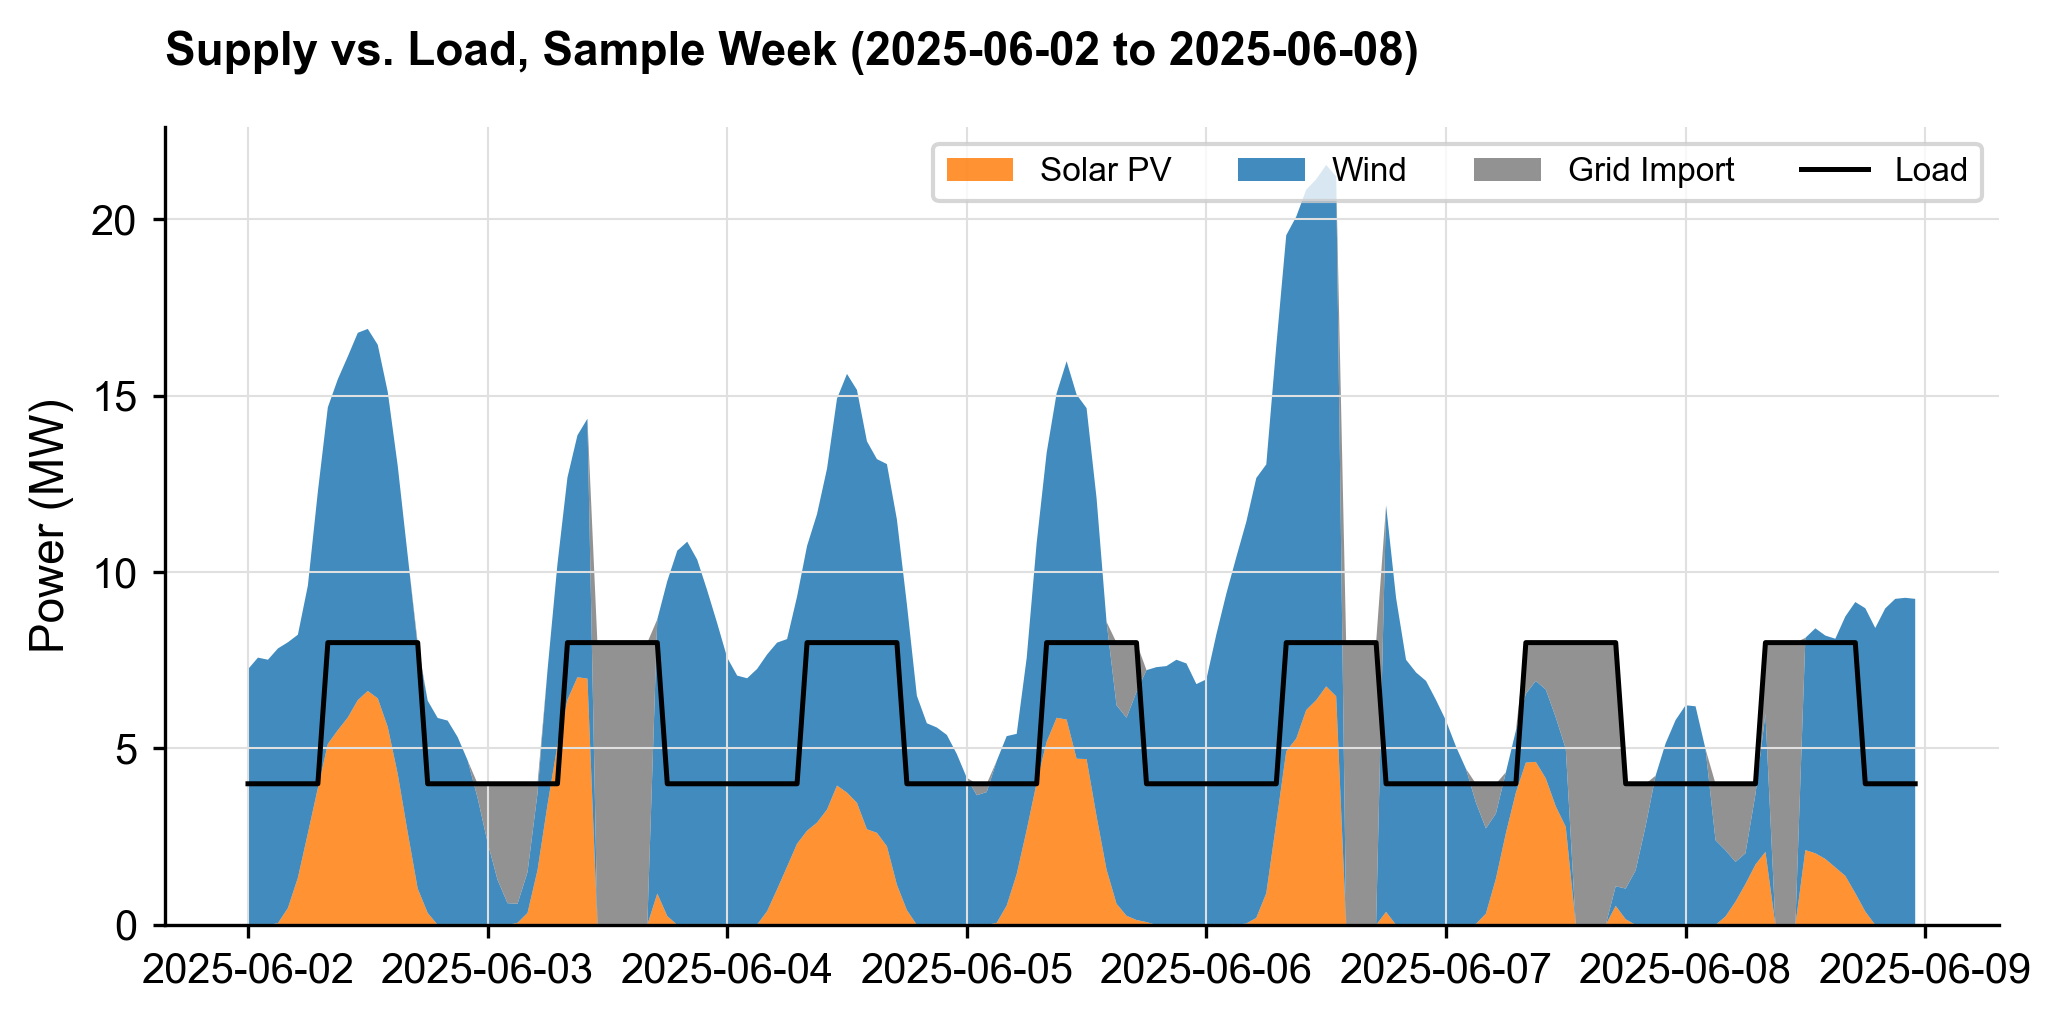

In [8]:
# Calculate Annual Totals
total_solar_mwh = n.generators_t.p['Solar_PV'].sum()
total_wind_mwh = n.generators_t.p['Wind'].sum()
total_re_mwh = total_solar_mwh + total_wind_mwh
total_import_mwh = n.generators_t.p['Grid_Import'].sum()
total_export_mwh = -n.generators_t.p['Grid_Export'].sum()
total_load_mwh = load_profile.sum()

# Self-consumption = renewable generation that did not leave via Grid_Export
total_self_consumed_mwh = total_re_mwh - total_export_mwh

import_cost_eur = (n.generators_t.p['Grid_Import'] * df_price['price']).sum()
export_revenue_eur = (n.generators_t.p['Grid_Export'] * -1 * df_price['price']).sum()

print(f"Total Annual Load:             {total_load_mwh:,.2f} MWh")
print(f"Total Renewable Production:    {total_re_mwh:,.2f} MWh")
print(f"Self-Consumed (RE -> Load):    {total_self_consumed_mwh:,.2f} MWh ({100*total_self_consumed_mwh/total_load_mwh:.1f}% of load)")
print(f"Grid Import (shortfall):       {total_import_mwh:,.2f} MWh")
print("-" * 40)
print(f"Grid Import Cost:              €{import_cost_eur:,.2f}")
print(f"Grid Export Revenue:           €{export_revenue_eur:,.2f}")
print(f"Net Cost:                      €{import_cost_eur - export_revenue_eur:,.2f}")
print("Negative Net Cost indicates that the system is profitable, i.e., the revenue from exporting excess renewable energy exceeds the cost of importing electricity to meet demand.")

# Plot one representative week to visualize supply vs. load
week = (n.snapshots >= '2025-06-02') & (n.snapshots < '2025-06-09')

fig, ax = plt.subplots()

ax.stackplot(n.snapshots[week],
             n.generators_t.p['Solar_PV'][week],
             n.generators_t.p['Wind'][week],
             n.generators_t.p['Grid_Import'][week],
             labels=['Solar PV', 'Wind', 'Grid Import'],
             colors=['#ff7f0e', '#1f77b4', '#7f7f7f'], alpha=0.85)
ax.plot(n.snapshots[week], load_profile[week], color='black', linewidth=1.2, label='Load')

ax.set_ylabel('Power (MW)')
ax.set_title('Supply vs. Load, Sample Week (2025-06-02 to 2025-06-08)', pad=15, loc='left', fontweight='bold')
ax.legend(loc='upper right', ncol=4, fontsize=8)

plt.tight_layout()
plt.show()
